In [54]:
from pathlib import Path
import neurokit2 as nk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [55]:
BASE_PATH = Path("../data/processed/dalia")
PATIENTS = [f"S{i}" for i in range(1, 16)]  # S1 to S15

print(f"Base path: {BASE_PATH}")
print(f"Patients to analyze: {PATIENTS}")
print(f"Total patients: {len(PATIENTS)}")


def load_patient_ecg(patient_id: str, base_path: Path) -> pd.DataFrame:
    """
    Load ecg for a specific patient from chest_ECG.csv.

    Parameters
    ----------
    patient_id : str
        Patient ID (e.g., 'S1', 'S2', etc.)
    base_path : Path
        Base path to the DALIA dataset

    Returns
    -------
    pd.DataFrame
        DataFrame containing the chest_ECG.csv data
    """
    ecg_path = base_path / patient_id / "chest/chest_ECG.csv"

    if not ecg_path.exists():
        raise FileNotFoundError(f"ECG file not found: {ecg_path}")

    # Read CSV file - assumes first column contains ecg values
    df = pd.read_csv(ecg_path)
    return df


Base path: ..\data\processed\dalia
Patients to analyze: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
Total patients: 15


In [56]:
def extract_random_chunk(ecg_data: pd.DataFrame, chunk_size: int = 7000) -> tuple:
    """
    Extract a random chunk of specified size from ECG data.

    Parameters
    ----------
    ecg_data : pd.DataFrame
        DataFrame containing ECG values
    chunk_size : int, optional
        Size of the chunk to extract (default: 7000)

    Returns
    -------
    tuple
        (chunk_data, start_index) - the chunk and its starting index
    """
    total_length = len(ecg_data)

    if chunk_size > total_length:
        print(f"Warning: Chunk size ({chunk_size}) is larger than data length "
              f"({total_length}). Using full data.")
        return ecg_data, 0

    # Pick a random starting position
    start_idx = np.random.randint(0, total_length - chunk_size + 1)
    end_idx = start_idx + chunk_size

    chunk = ecg_data.iloc[start_idx:end_idx]
    return chunk, start_idx


def plot_ecg_chunk(patient_id: str, chunk: pd.DataFrame, start_idx: int):
    """
    Plot a chunk of ECG data for a patient.

    Parameters
    ----------
    patient_id : str
        Patient ID for display purposes
    chunk : pd.DataFrame
        ECG data chunk to plot
    start_idx : int
        Starting index of the chunk in the original data
    """
    fig, ax = plt.subplots(figsize=(14, 4))

    # Get the first column (ECG values)
    ecg_values = chunk.iloc[:, 0].values

    ax.plot(ecg_values, linewidth=0.8, color='steelblue')
    ax.set_title(f'ECG Data - Patient {patient_id} '
                 f'(Records {start_idx} to {start_idx + len(chunk)})',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Sample Index (within chunk)', fontsize=12)
    ax.set_ylabel('ECG Value (mV)', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [57]:
print("Functions defined successfully ✓")


Functions defined successfully ✓


In [58]:
# Extract and store random ECG chunks for all patients
CHUNK_SIZE = 7000

# Dictionary to store chunks and metadata for each patient
patient_chunks = {}

print(f"\nExtracting random {CHUNK_SIZE}-sample chunks for each patient...")
print("=" * 70)

for patient_id in PATIENTS:
    try:
        print(f"\nProcessing {patient_id}...")

        # Load ECG data
        ecg_data = load_patient_ecg(patient_id, BASE_PATH)
        print(f"  Total ECG samples: {len(ecg_data)}")

        # Extract random chunk
        chunk, start_idx = extract_random_chunk(ecg_data, chunk_size=CHUNK_SIZE)
        print(f"  Random chunk extracted: indices {start_idx} to {start_idx + len(chunk)}")

        # Store chunk and metadata
        patient_chunks[patient_id] = {
            'chunk': chunk,
            'start_idx': start_idx,
            'end_idx': start_idx + len(chunk),
            'chunk_size': len(chunk),
            'total_samples': len(ecg_data)
        }
        print(f"  ✓ Chunk stored in patient_chunks['{patient_id}']")

    except FileNotFoundError as e:
        print(f"  ✗ Error: {e}")
    except Exception as e:
        print(f"  ✗ Unexpected error: {e}")

print("\n" + "=" * 70)
print(f"All patients processed ✓")
print(f"Total chunks stored: {len(patient_chunks)}")
print(f"\nAccess chunks using: patient_chunks['PATIENT_ID']['chunk']")



Extracting random 7000-sample chunks for each patient...

Processing S1...
  Total ECG samples: 6448400
  Random chunk extracted: indices 5077373 to 5084373
  ✓ Chunk stored in patient_chunks['S1']

Processing S2...
  Total ECG samples: 5743500
  Random chunk extracted: indices 4388657 to 4395657
  ✓ Chunk stored in patient_chunks['S2']

Processing S3...
  Total ECG samples: 6118700
  Random chunk extracted: indices 4857730 to 4864730
  ✓ Chunk stored in patient_chunks['S3']

Processing S4...
  Total ECG samples: 6405000
  Random chunk extracted: indices 3525797 to 3532797
  ✓ Chunk stored in patient_chunks['S4']

Processing S5...
  Total ECG samples: 6513500
  Random chunk extracted: indices 4451931 to 4458931
  ✓ Chunk stored in patient_chunks['S5']

Processing S6...
  Total ECG samples: 3675000
  Random chunk extracted: indices 1461731 to 1468731
  ✓ Chunk stored in patient_chunks['S6']

Processing S7...
  Total ECG samples: 6540100
  Random chunk extracted: indices 5532916 to 5539

Plotting all patient ECG chunks...

Plotting S1...


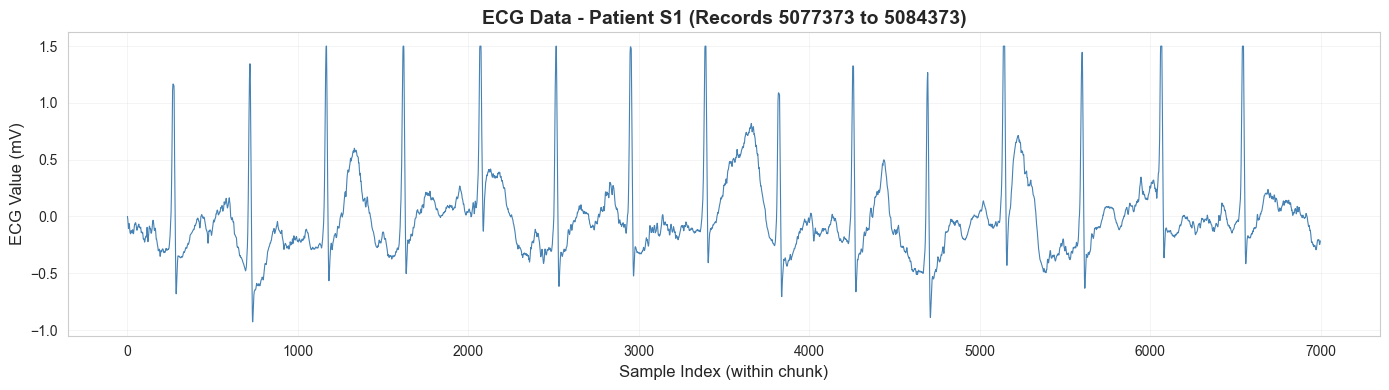


Plotting S2...


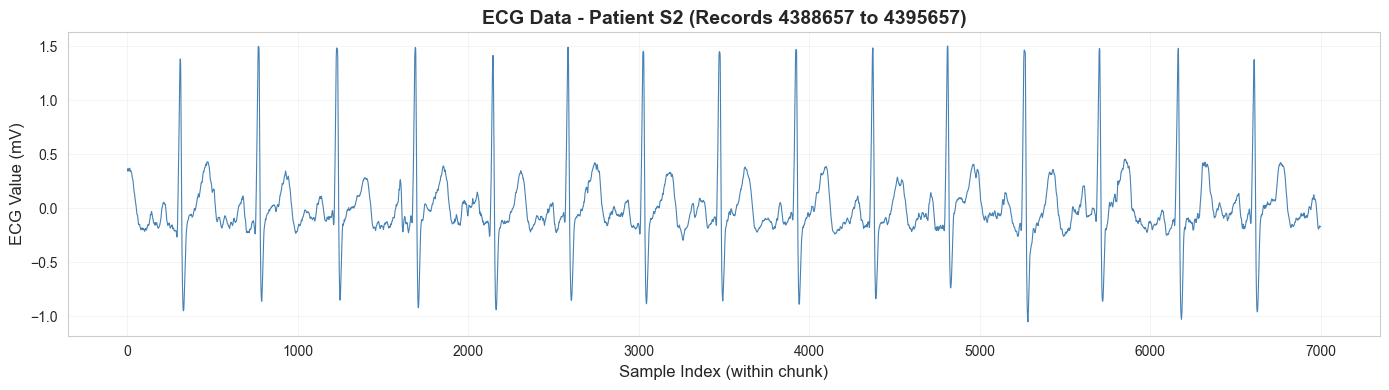


Plotting S3...


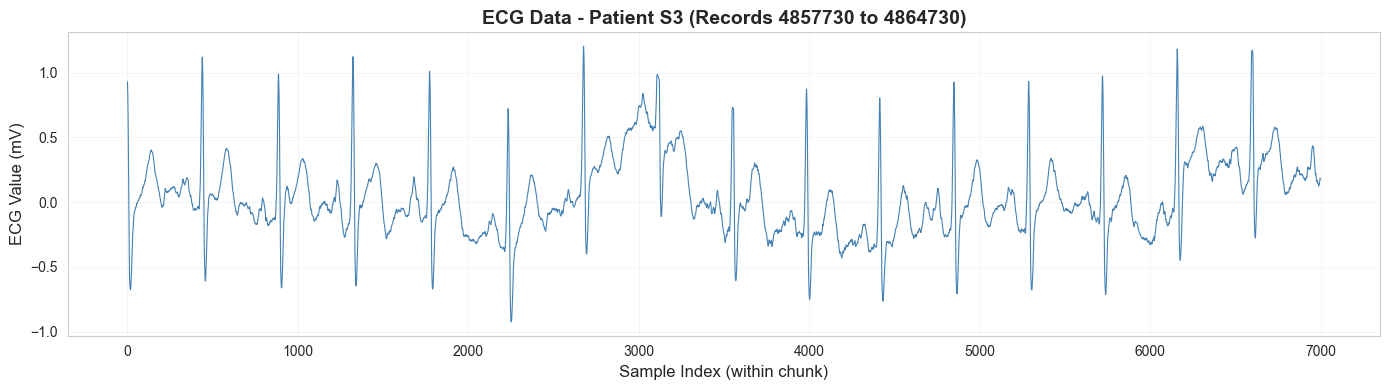


Plotting S4...


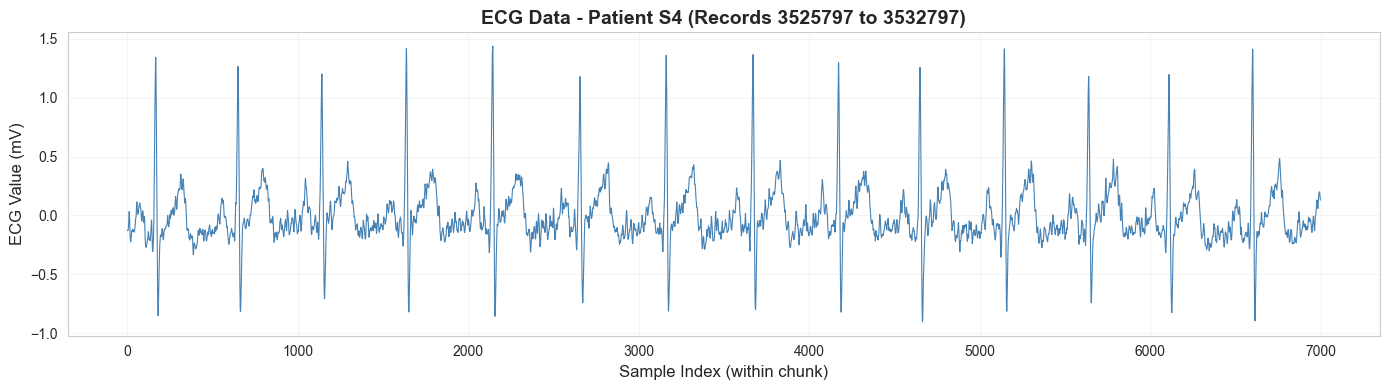


Plotting S5...


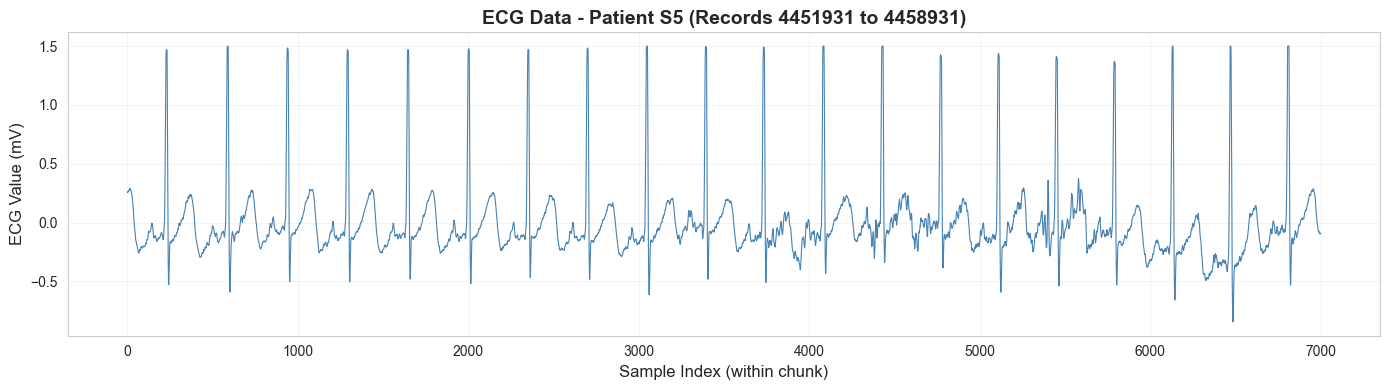


Plotting S6...


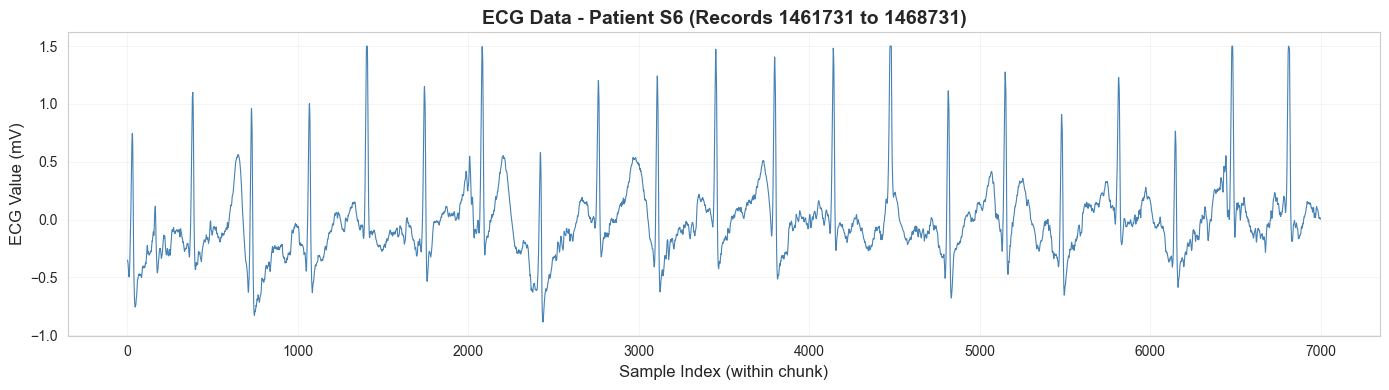


Plotting S7...


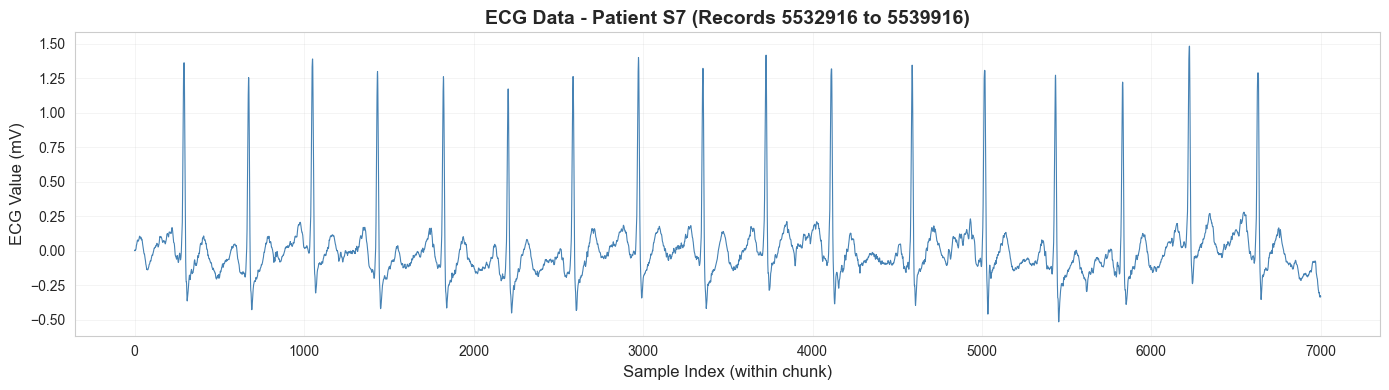


Plotting S8...


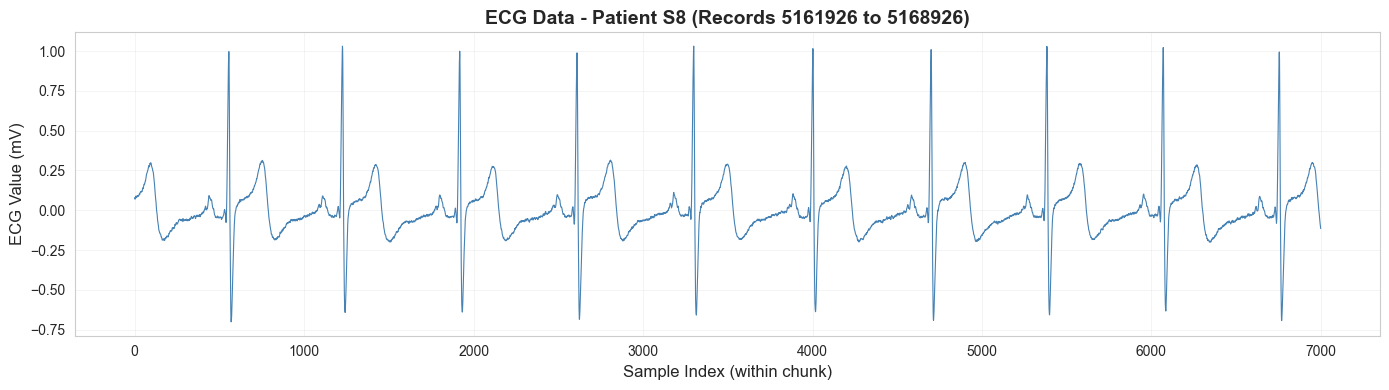


Plotting S9...


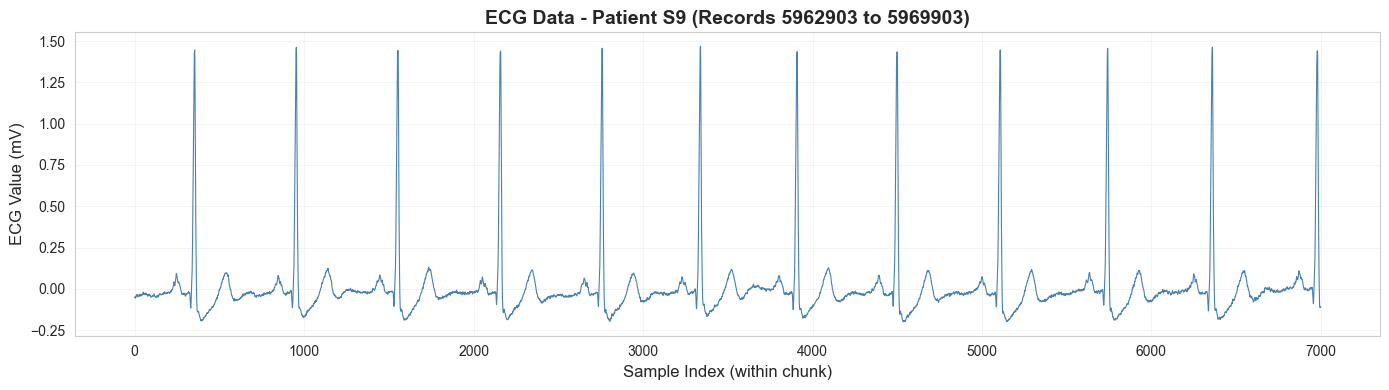


Plotting S10...


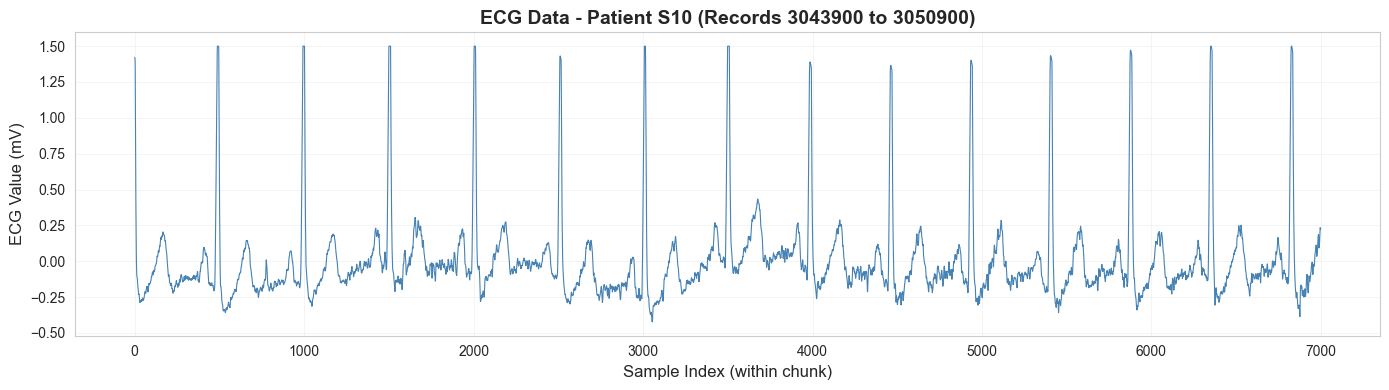


Plotting S11...


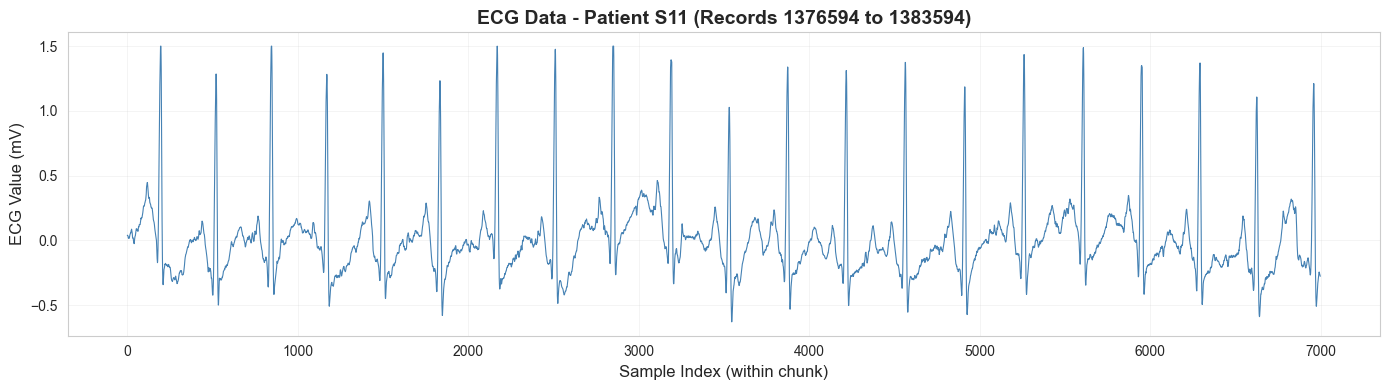


Plotting S12...


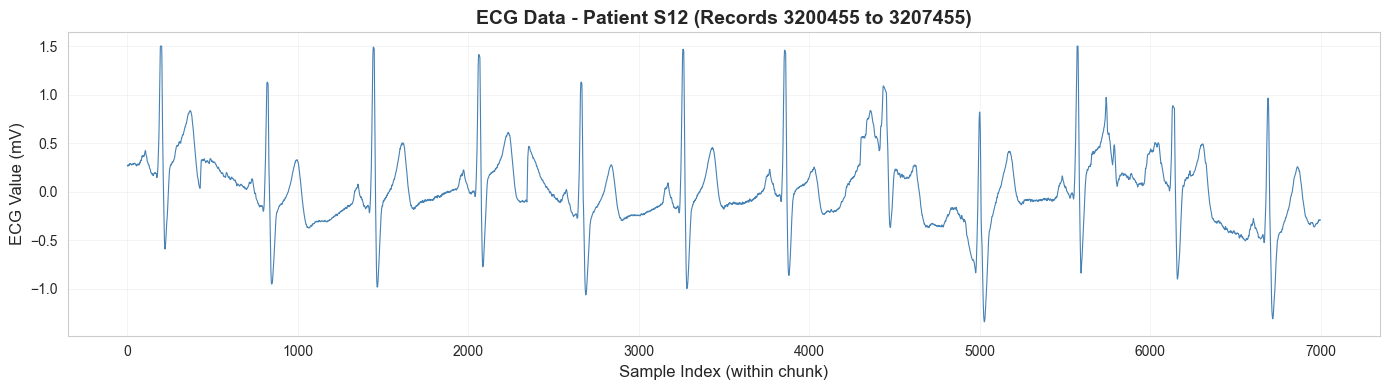


Plotting S13...


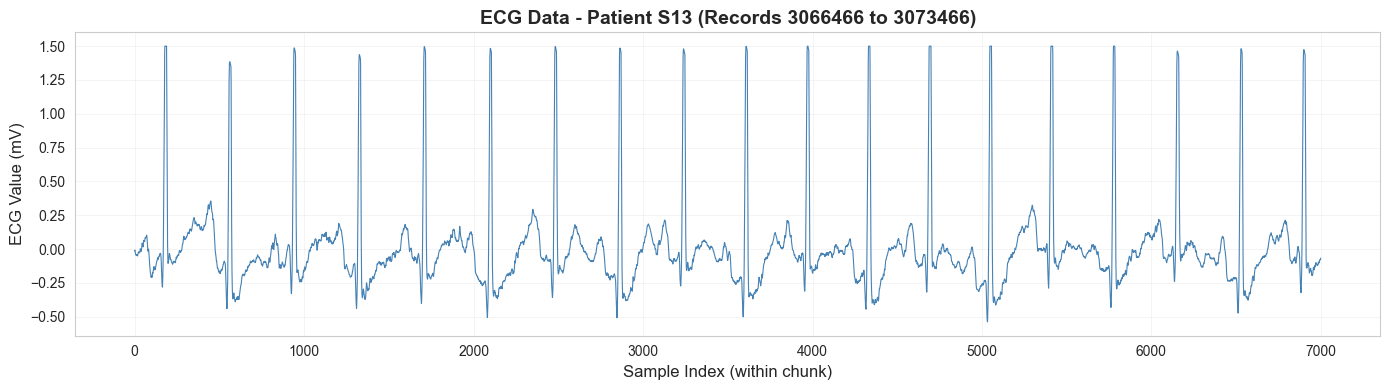


Plotting S14...


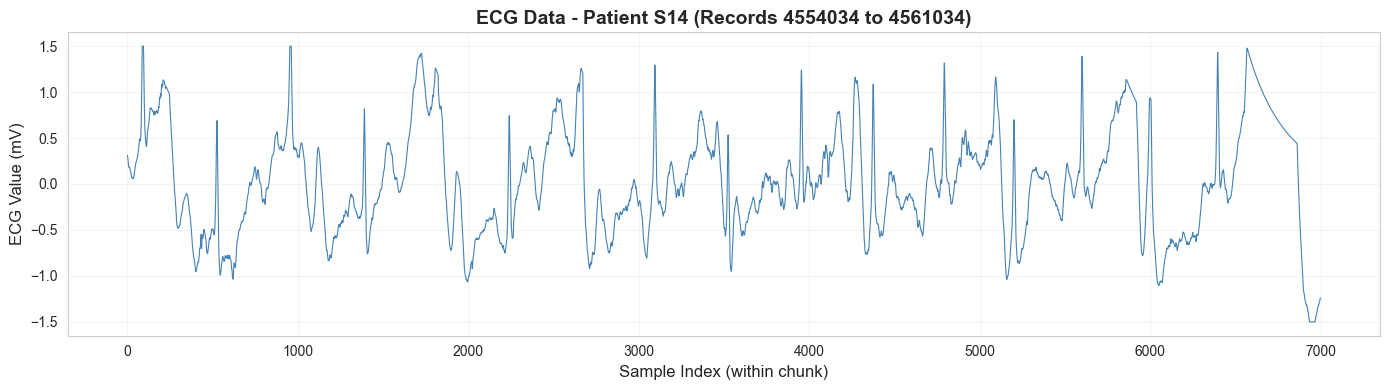


Plotting S15...


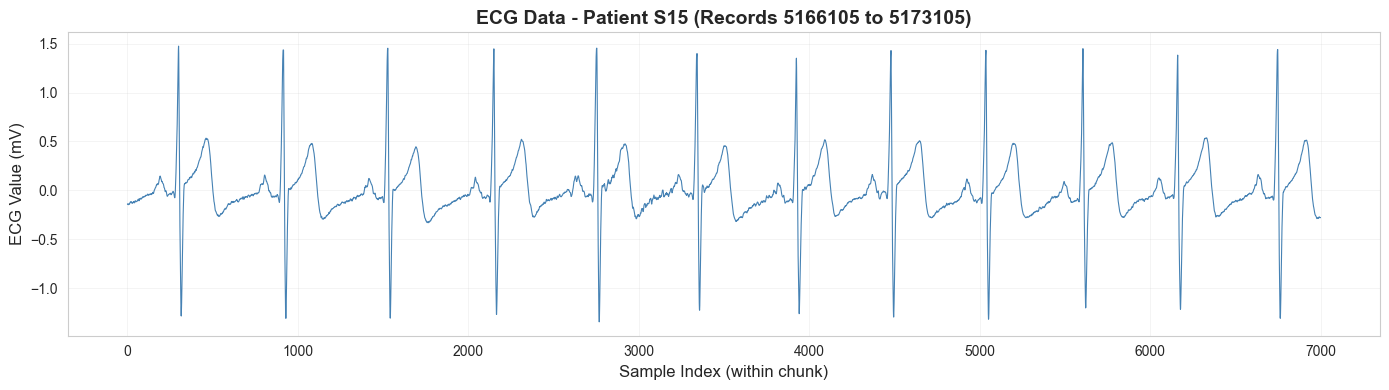


All plots displayed ✓


In [59]:
# Plot all stored chunks
print("Plotting all patient ECG chunks...")
print("=" * 70)

for patient_id, data in patient_chunks.items():
    print(f"\nPlotting {patient_id}...")
    plot_ecg_chunk(patient_id, data['chunk'], data['start_idx'])

print("\n" + "=" * 70)
print("All plots displayed ✓")

Comparing raw vs cleaned ECG for all patients...

Processing S1...


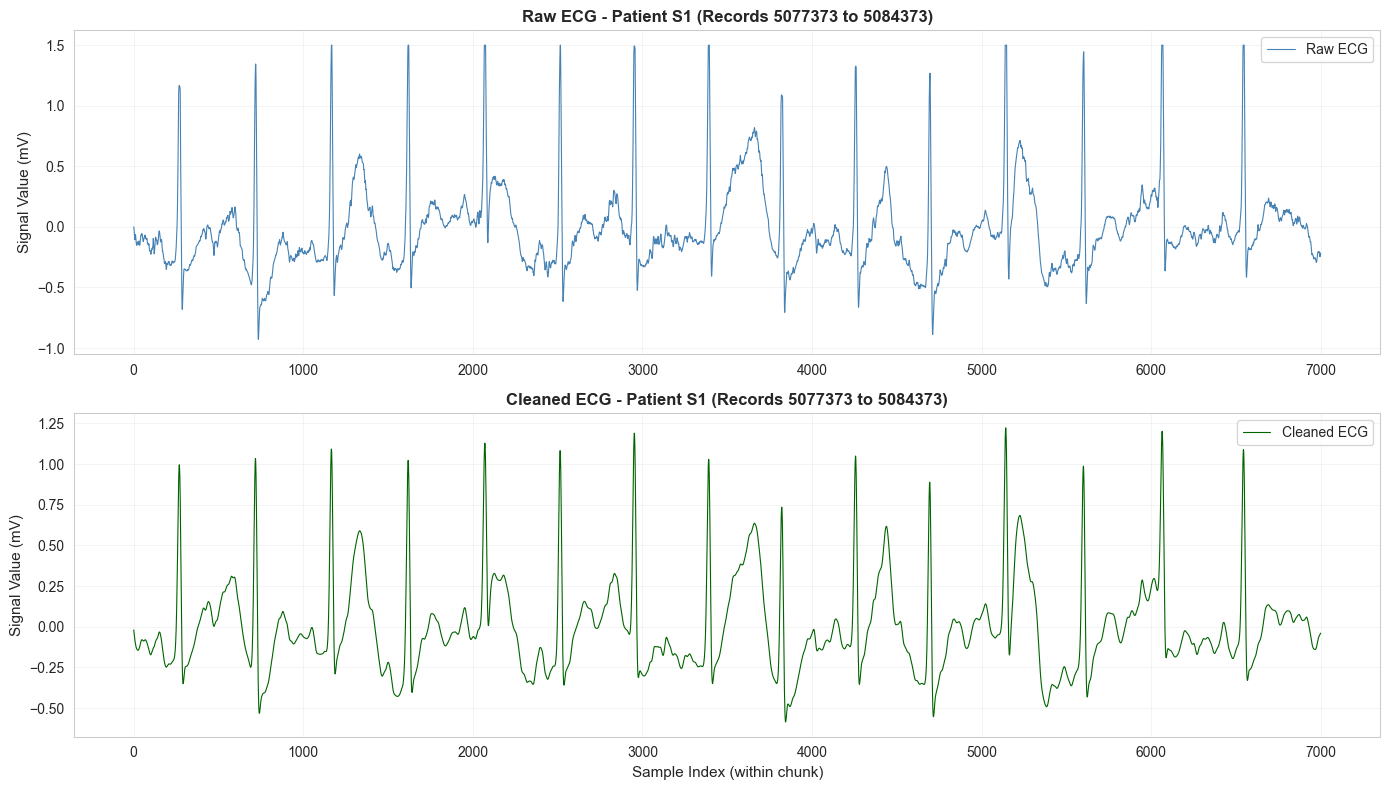

  Raw ECG - Mean: -0.0167, Std: 0.3370, Min: -0.9281, Max: 1.4995
  Cleaned ECG - Mean: -0.0024, Std: 0.2852, Min: -0.5857, Max: 1.2222

Processing S2...


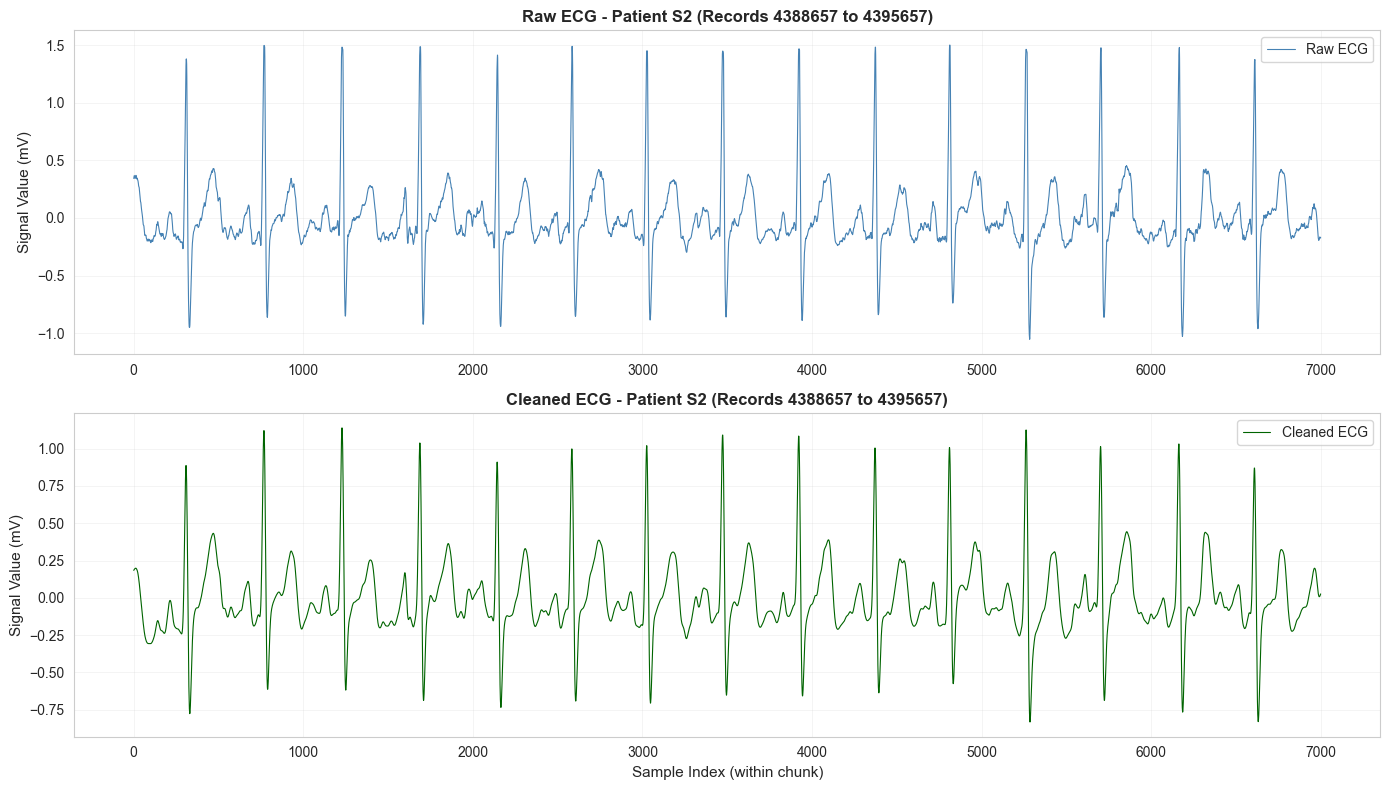

  Raw ECG - Mean: -0.0000, Std: 0.3111, Min: -1.0529, Max: 1.4992
  Cleaned ECG - Mean: -0.0039, Std: 0.2572, Min: -0.8326, Max: 1.1397

Processing S3...


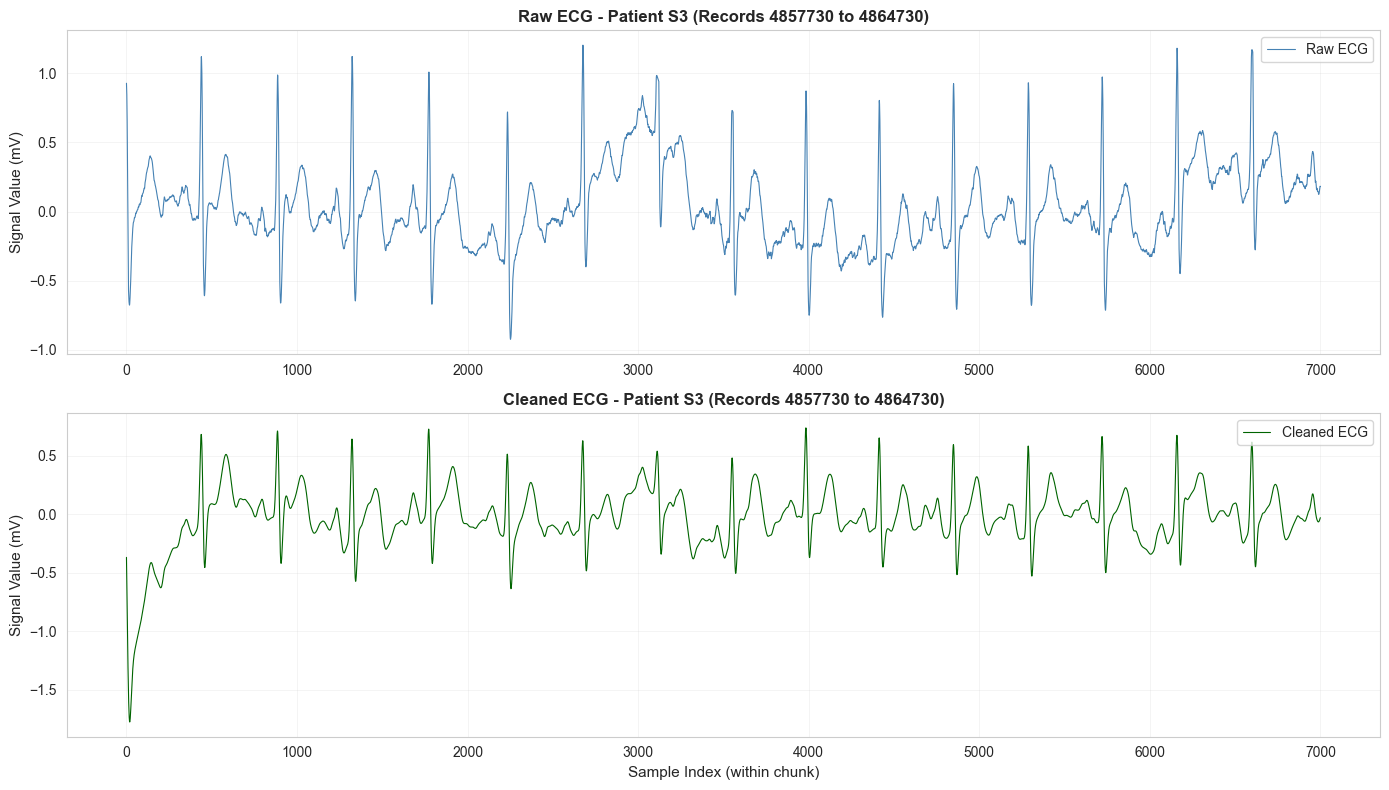

  Raw ECG - Mean: 0.0334, Std: 0.2929, Min: -0.9240, Max: 1.2038
  Cleaned ECG - Mean: -0.0243, Std: 0.2570, Min: -1.7750, Max: 0.7405

Processing S4...


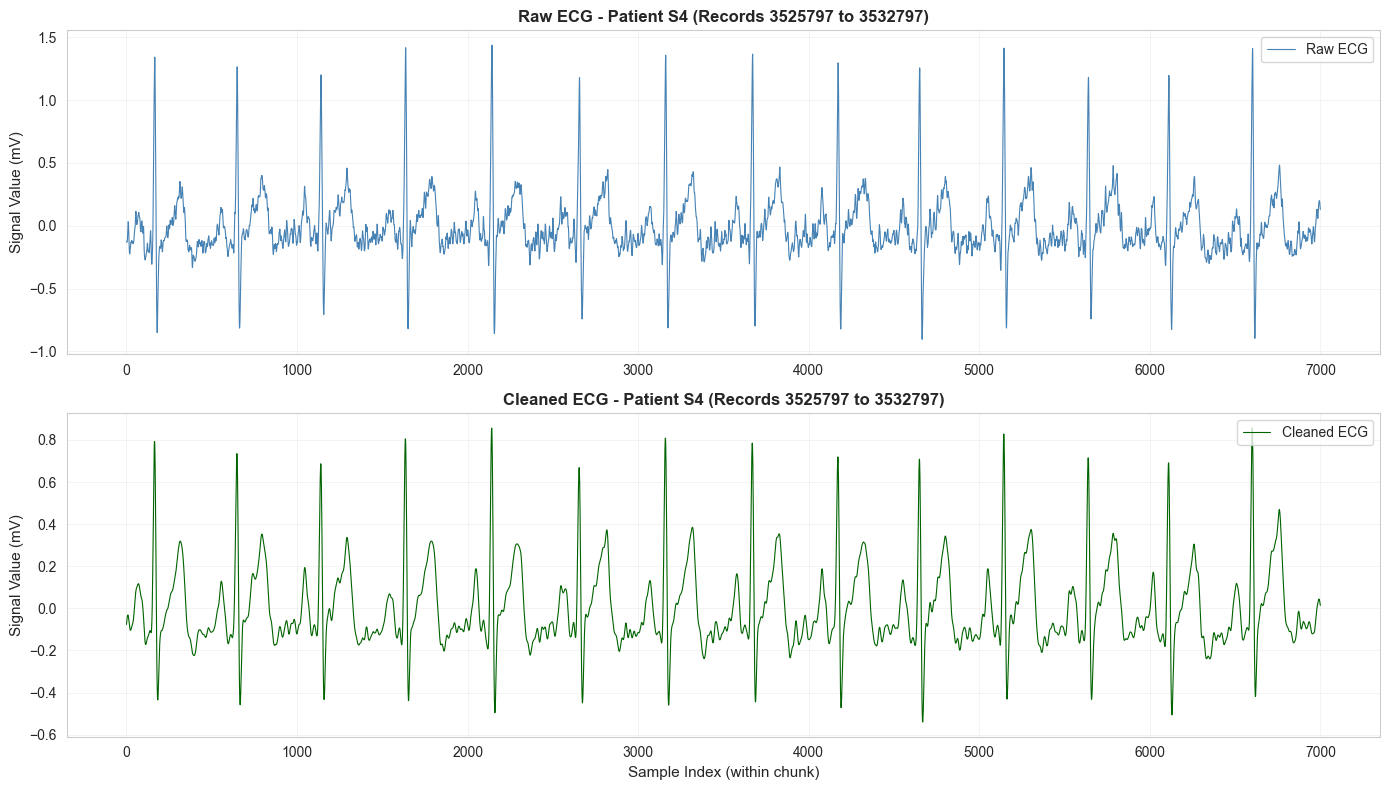

  Raw ECG - Mean: -0.0046, Std: 0.2470, Min: -0.9044, Max: 1.4383
  Cleaned ECG - Mean: -0.0001, Std: 0.1918, Min: -0.5398, Max: 0.8576

Processing S5...


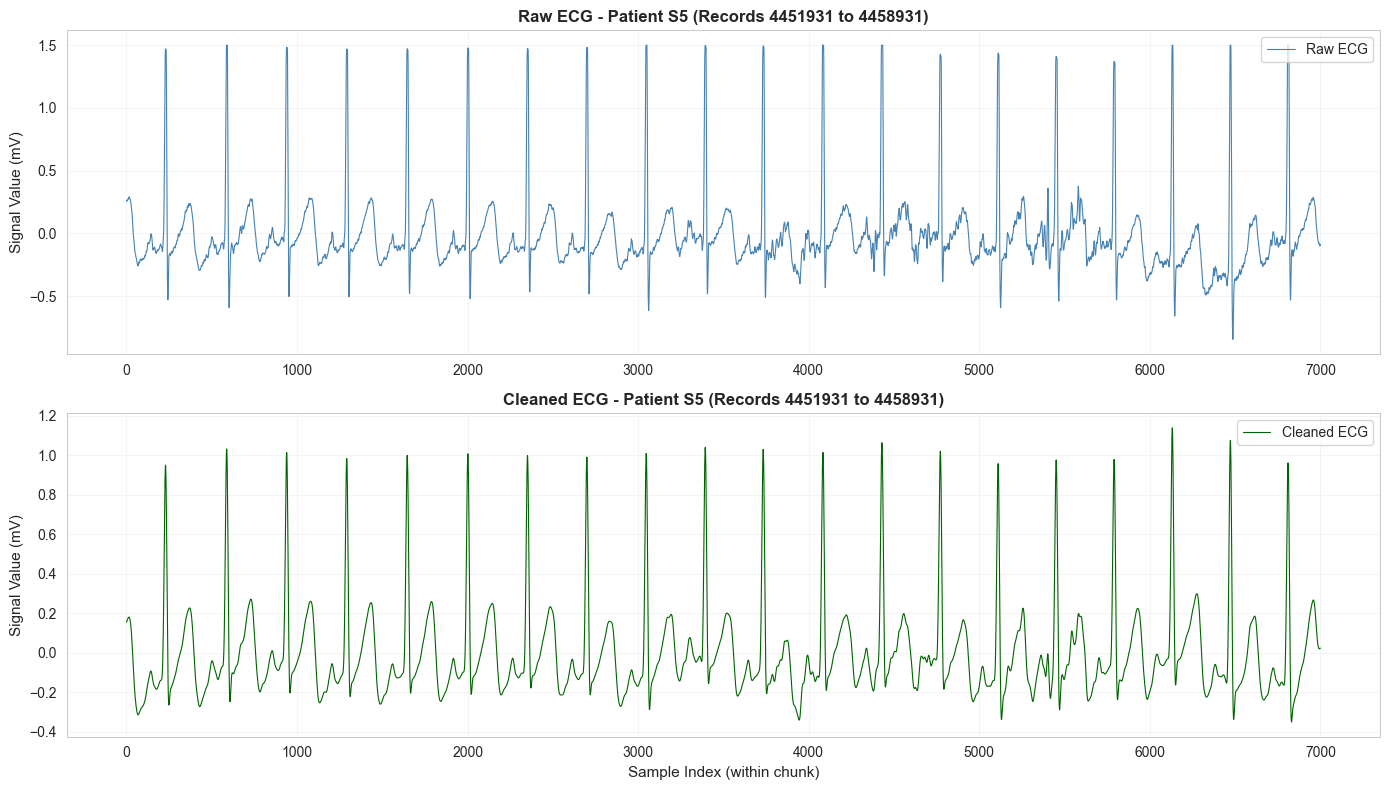

  Raw ECG - Mean: -0.0130, Std: 0.3095, Min: -0.8436, Max: 1.4995
  Cleaned ECG - Mean: -0.0027, Std: 0.2345, Min: -0.3499, Max: 1.1394

Processing S6...


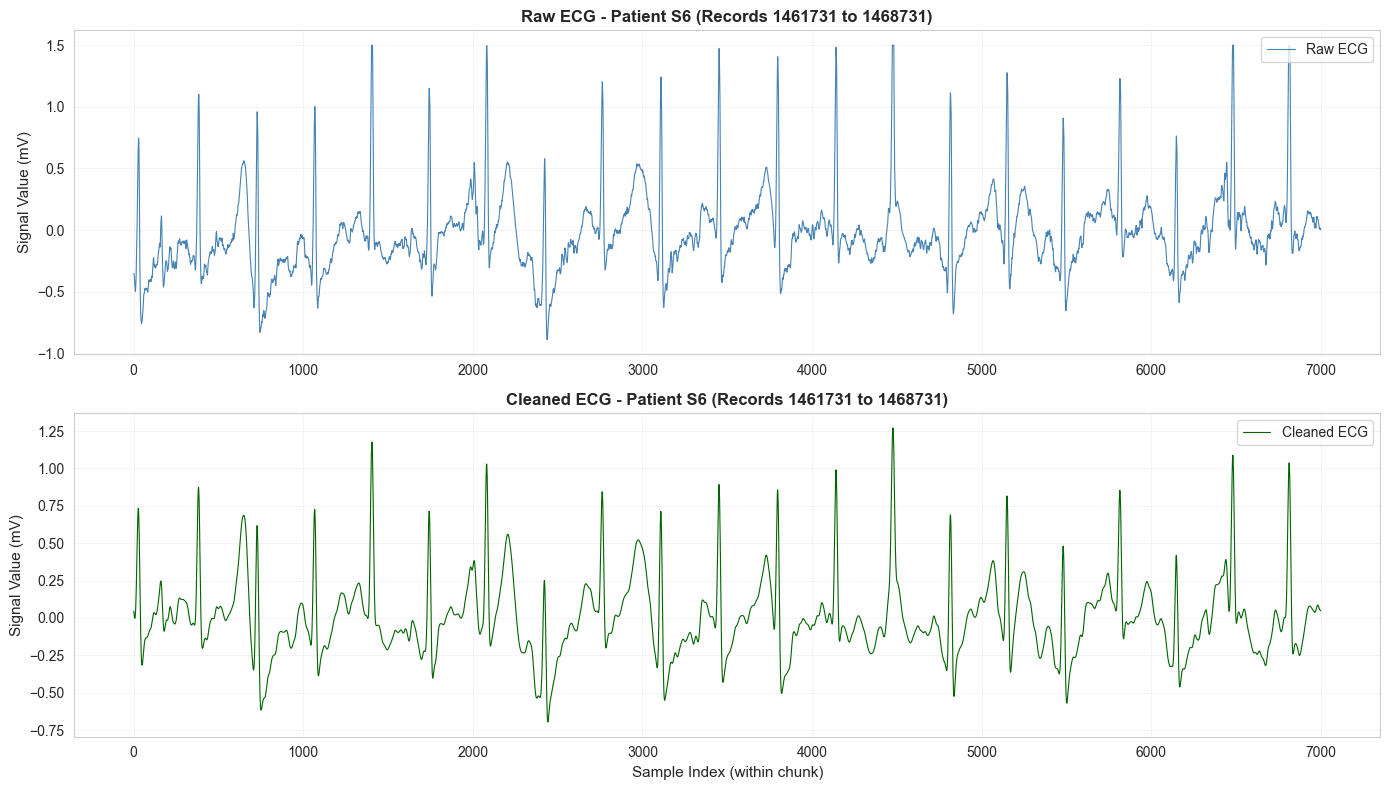

  Raw ECG - Mean: -0.0224, Std: 0.3181, Min: -0.8847, Max: 1.4992
  Cleaned ECG - Mean: 0.0029, Std: 0.2613, Min: -0.6961, Max: 1.2712

Processing S7...


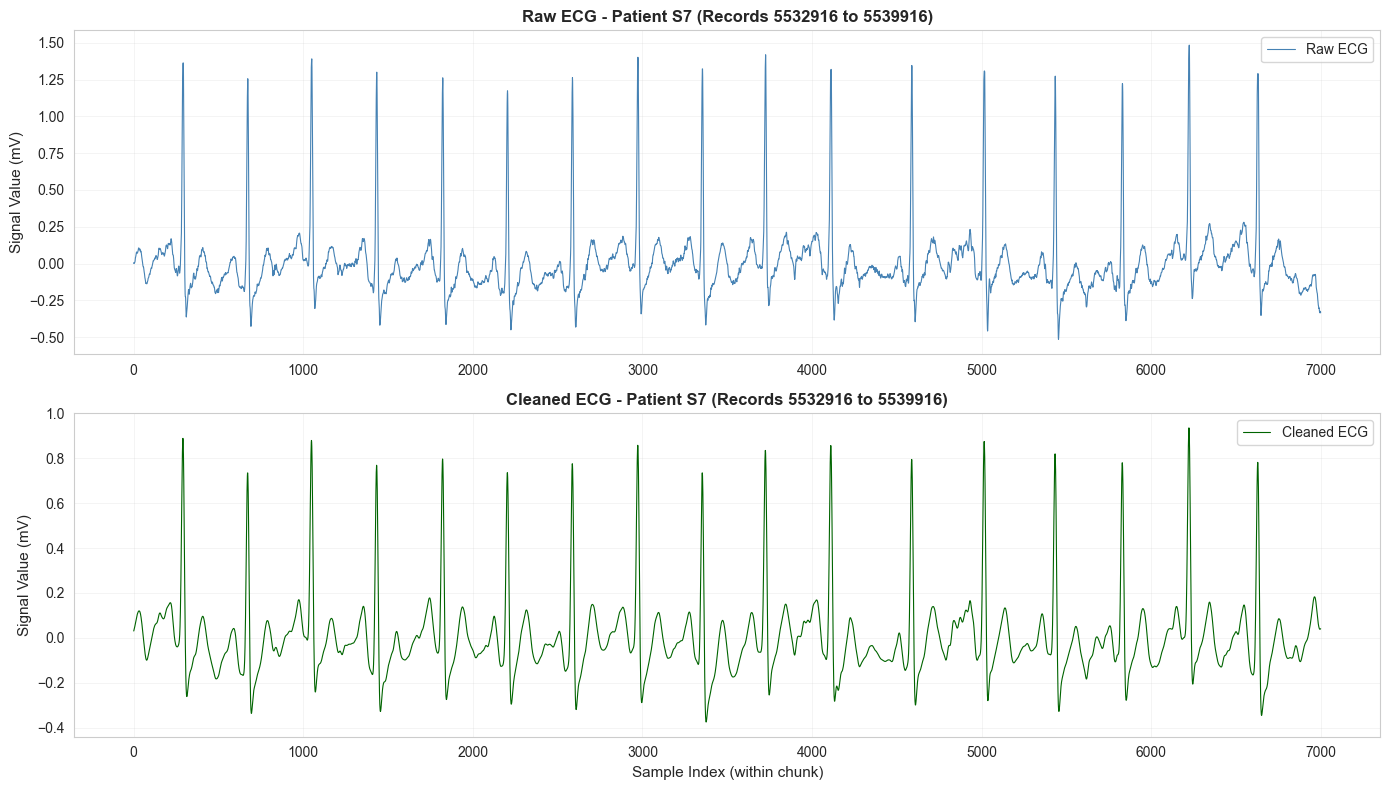

  Raw ECG - Mean: 0.0021, Std: 0.2280, Min: -0.5140, Max: 1.4834
  Cleaned ECG - Mean: 0.0011, Std: 0.1756, Min: -0.3752, Max: 0.9357

Processing S8...


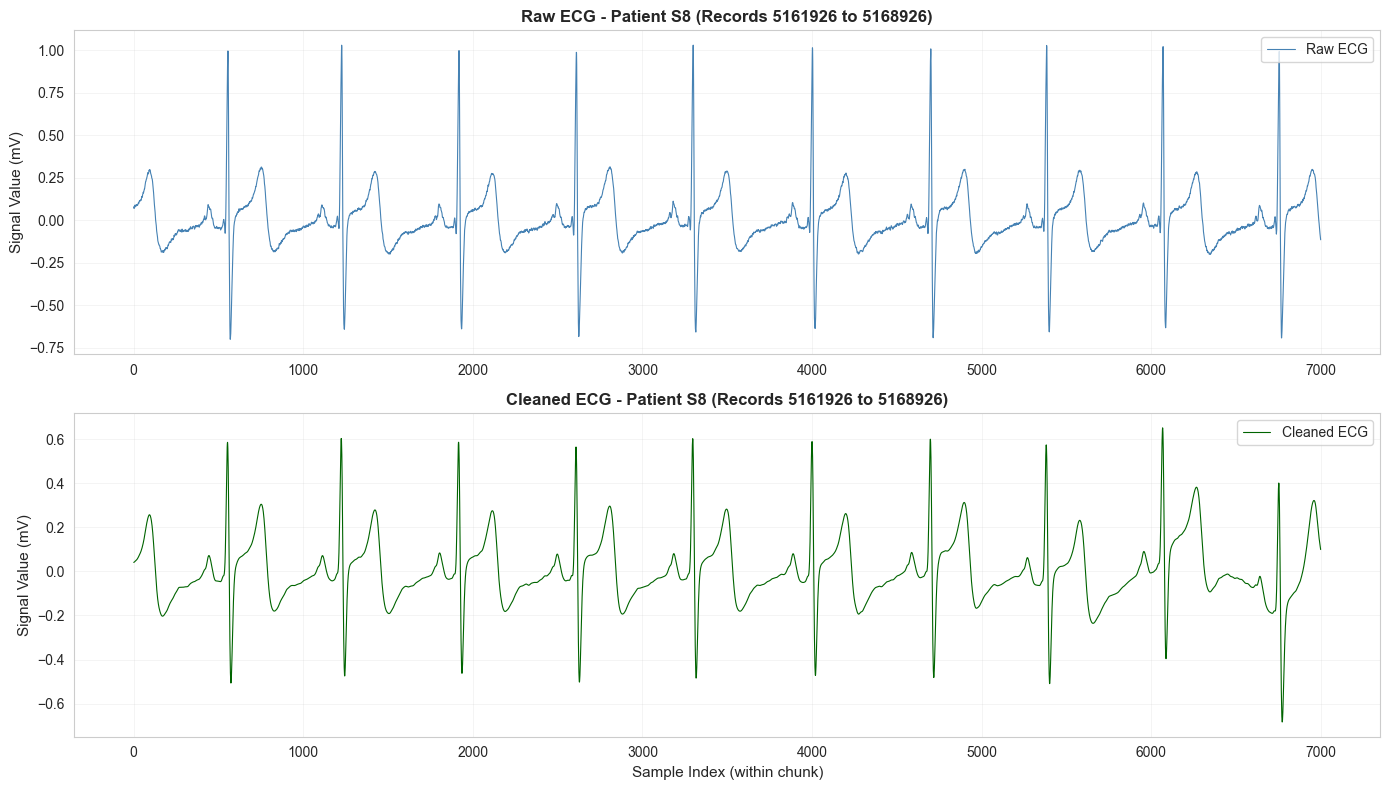

  Raw ECG - Mean: 0.0041, Std: 0.1773, Min: -0.7010, Max: 1.0311
  Cleaned ECG - Mean: -0.0004, Std: 0.1515, Min: -0.6835, Max: 0.6507

Processing S9...


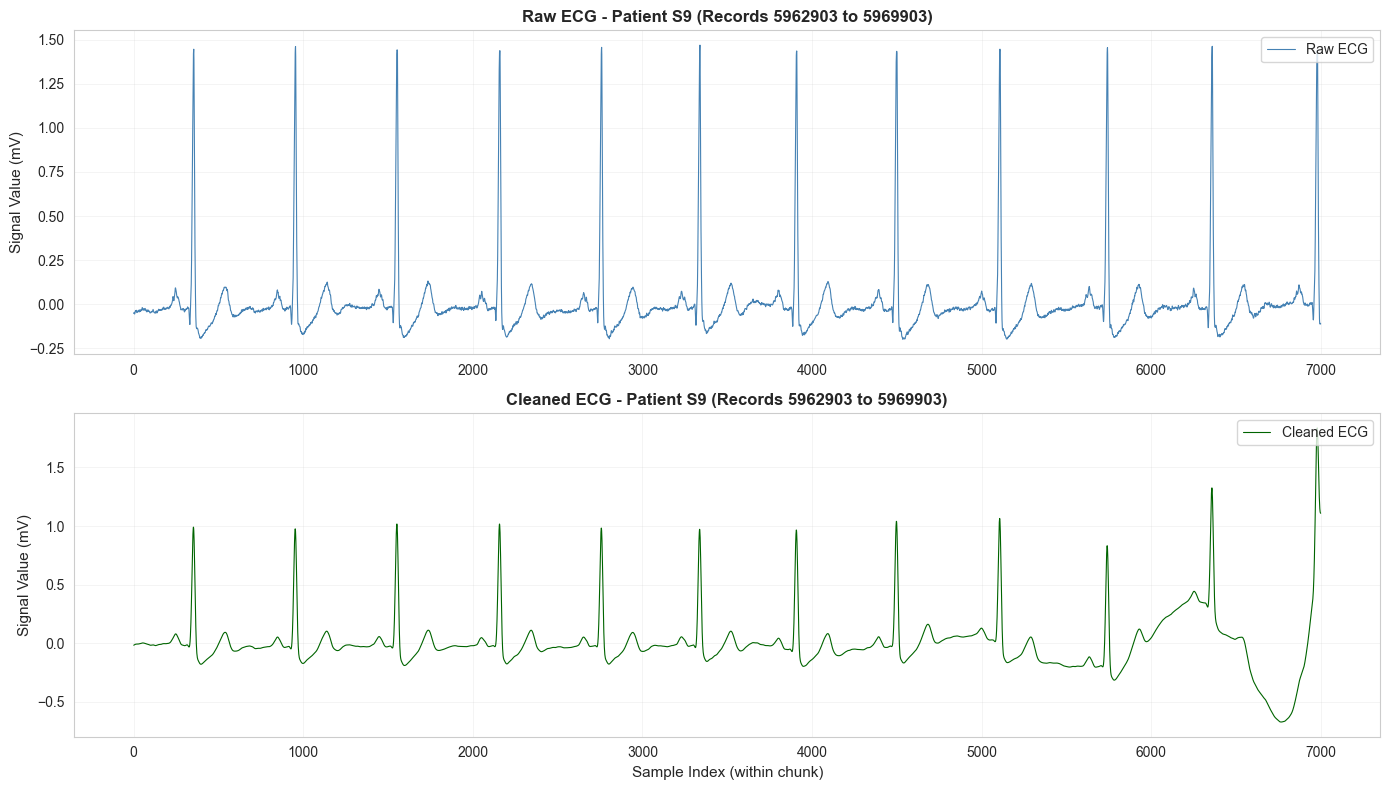

  Raw ECG - Mean: 0.0030, Std: 0.2039, Min: -0.1994, Max: 1.4696
  Cleaned ECG - Mean: -0.0019, Std: 0.2431, Min: -0.6719, Max: 1.8380

Processing S10...


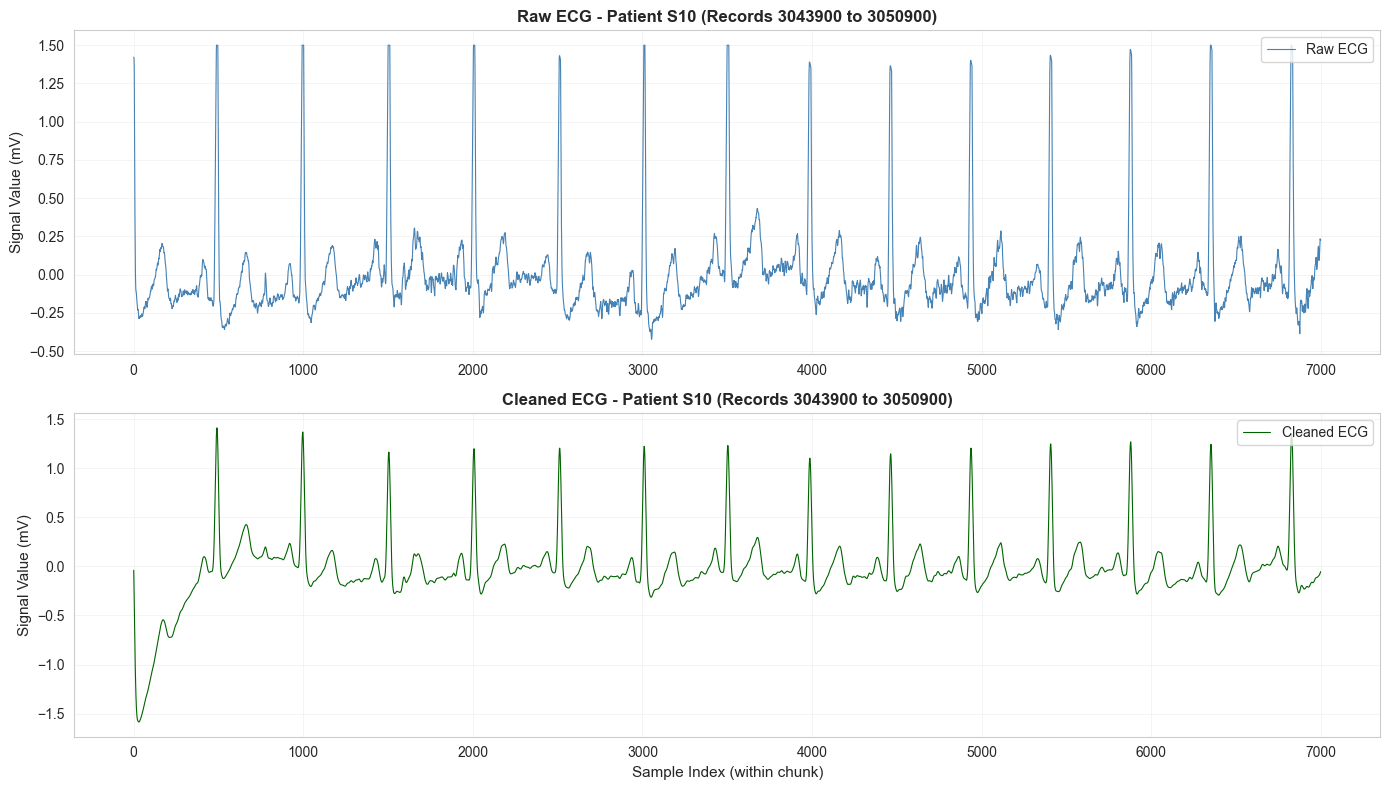

  Raw ECG - Mean: -0.0024, Std: 0.2947, Min: -0.4224, Max: 1.4996
  Cleaned ECG - Mean: -0.0304, Std: 0.3237, Min: -1.5857, Max: 1.4119

Processing S11...


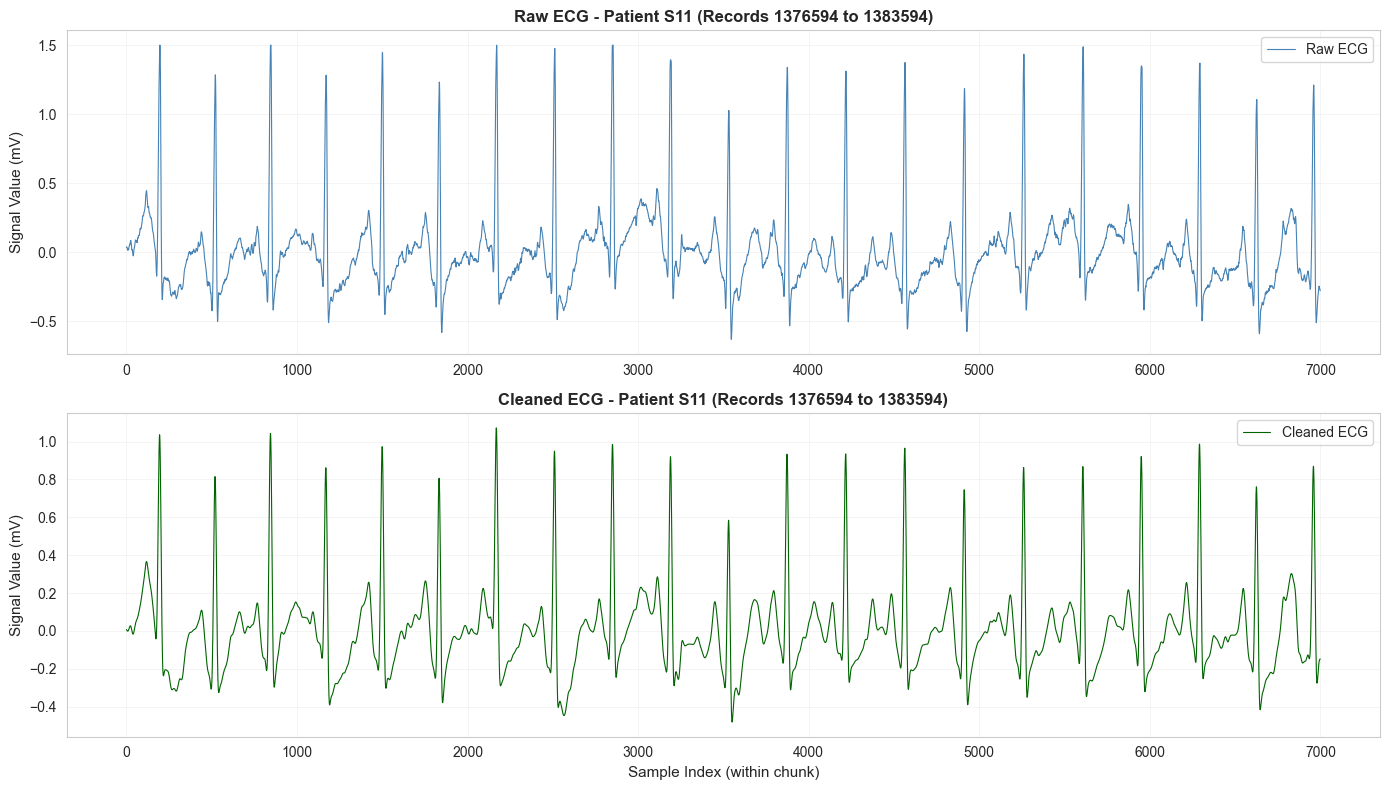

  Raw ECG - Mean: 0.0051, Std: 0.2955, Min: -0.6290, Max: 1.4994
  Cleaned ECG - Mean: 0.0013, Std: 0.2274, Min: -0.4807, Max: 1.0724

Processing S12...


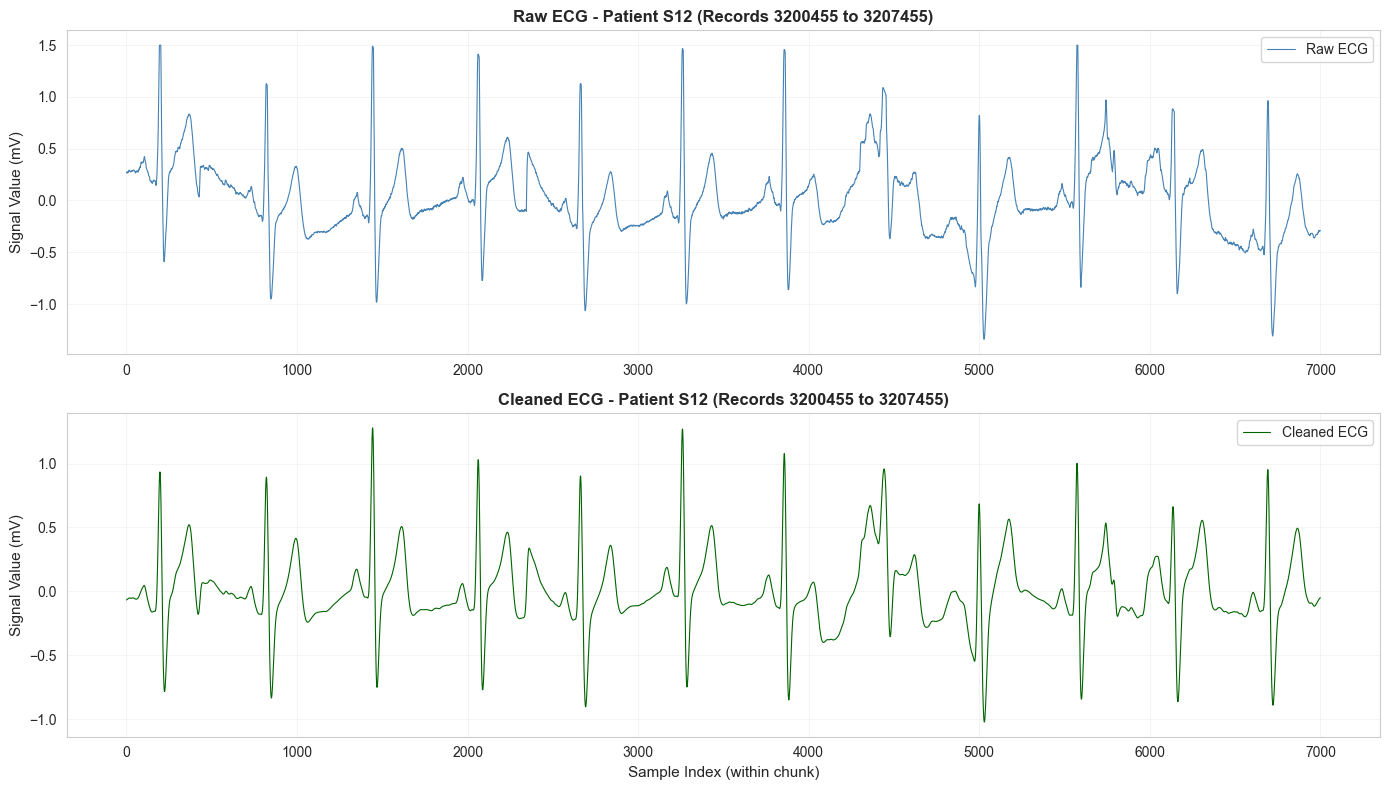

  Raw ECG - Mean: 0.0154, Std: 0.3690, Min: -1.3396, Max: 1.4995
  Cleaned ECG - Mean: 0.0015, Std: 0.2870, Min: -1.0211, Max: 1.2787

Processing S13...


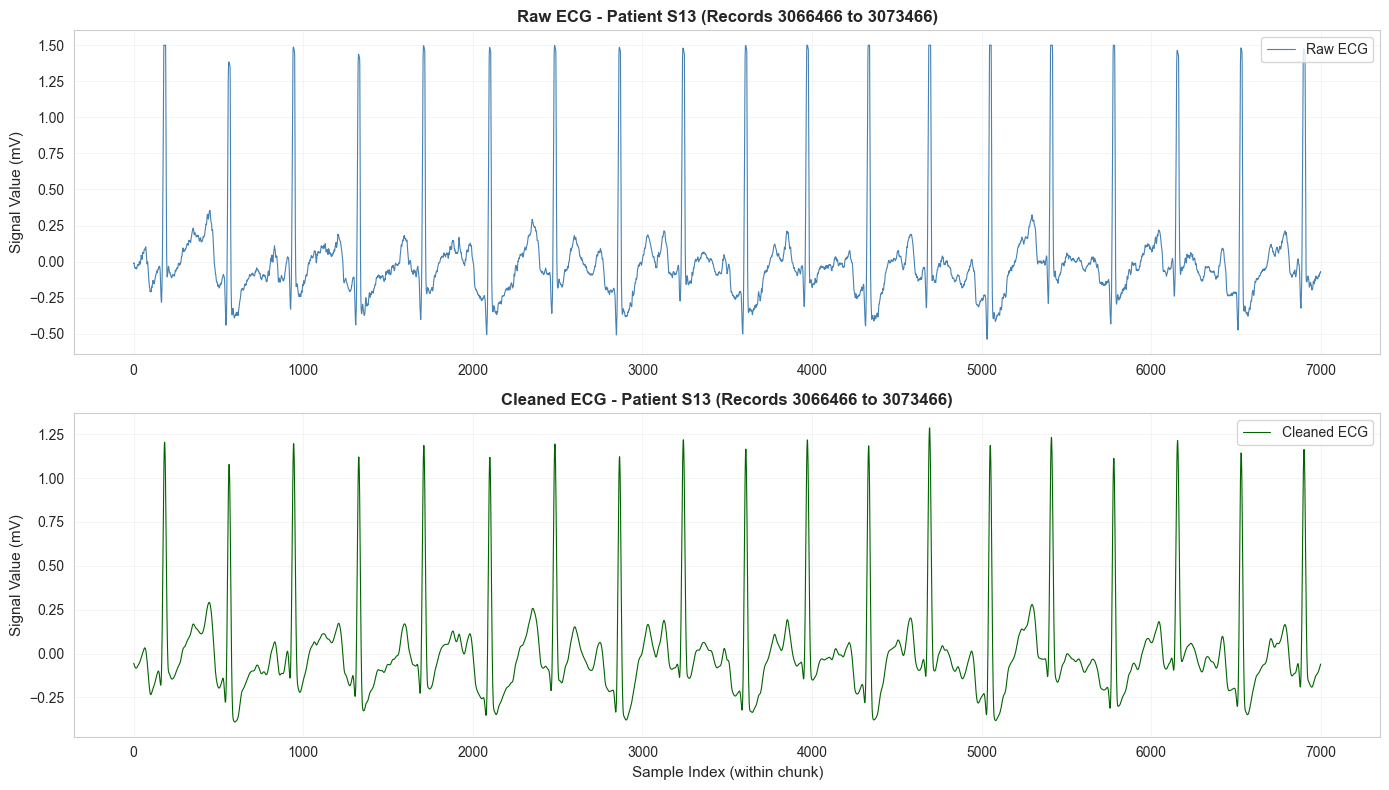

  Raw ECG - Mean: 0.0043, Std: 0.3264, Min: -0.5382, Max: 1.4994
  Cleaned ECG - Mean: 0.0006, Std: 0.2651, Min: -0.3899, Max: 1.2862

Processing S14...


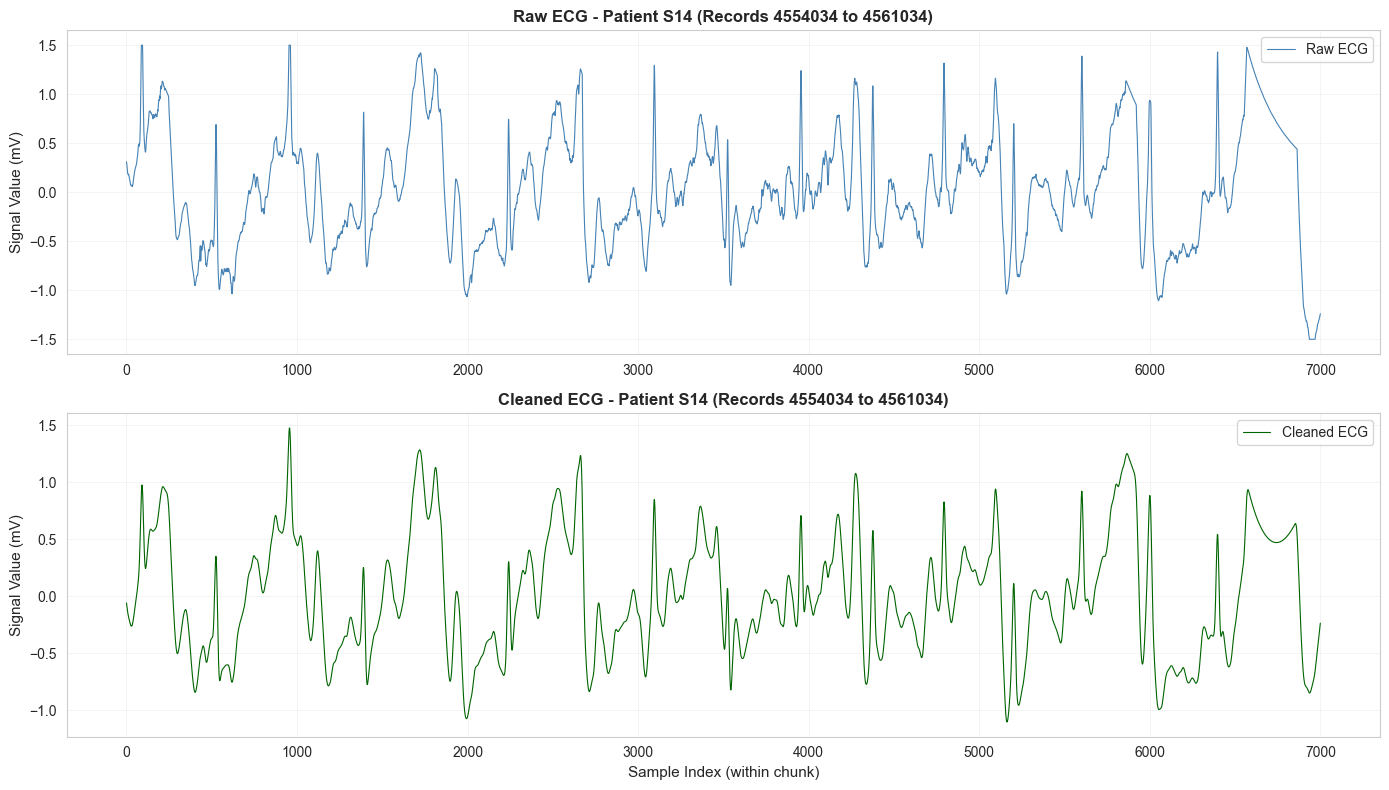

  Raw ECG - Mean: 0.0214, Std: 0.5753, Min: -1.4995, Max: 1.4995
  Cleaned ECG - Mean: 0.0028, Std: 0.5173, Min: -1.1041, Max: 1.4764

Processing S15...


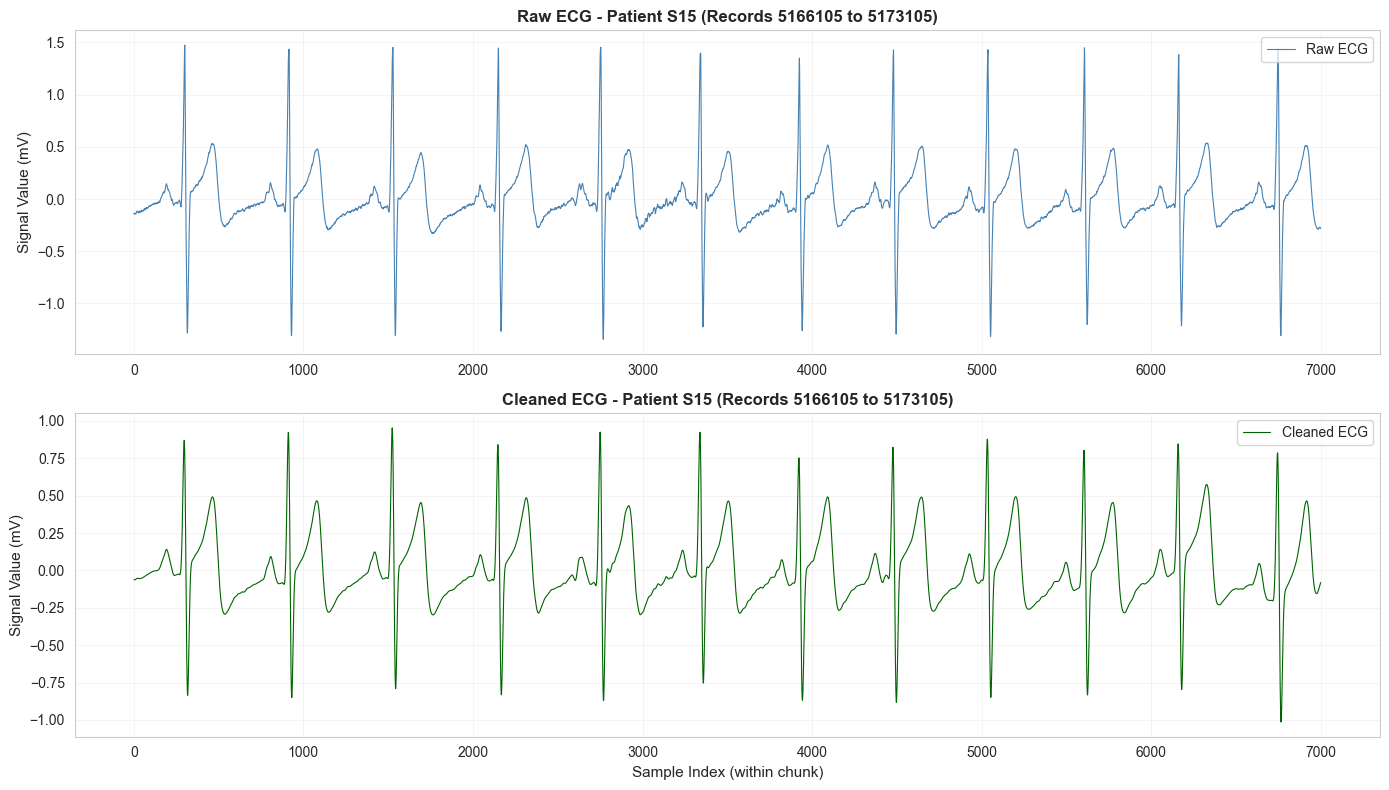

  Raw ECG - Mean: 0.0051, Std: 0.3014, Min: -1.3429, Max: 1.4740
  Cleaned ECG - Mean: 0.0013, Std: 0.2503, Min: -1.0135, Max: 0.9529

All comparisons displayed ✓


In [60]:
# Compare raw ECG vs cleaned ECG side by side
print("Comparing raw vs cleaned ECG for all patients...")
print("=" * 70)

for patient_id, data in patient_chunks.items():
    print(f"\nProcessing {patient_id}...")

    # Extract raw ECG values
    raw_ecg = data['chunk'].iloc[:, 0].values

    # Clean ECG with neurokit2
    cleaned_ecg = nk.ecg_clean(raw_ecg, sampling_rate=700)

    # Create side-by-side comparison plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot raw ECG
    axes[0].plot(raw_ecg, linewidth=0.8, color='steelblue', label='Raw ECG')
    axes[0].set_title(f'Raw ECG - Patient {patient_id} '
                      f'(Records {data["start_idx"]} to {data["end_idx"]})',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Signal Value (mV)', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')

    # Plot cleaned ECG
    axes[1].plot(cleaned_ecg, linewidth=0.8, color='darkgreen', label='Cleaned ECG')
    axes[1].set_title(f'Cleaned ECG - Patient {patient_id} '
                      f'(Records {data["start_idx"]} to {data["end_idx"]})',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Index (within chunk)', fontsize=11)
    axes[1].set_ylabel('Signal Value (mV)', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"  Raw ECG - Mean: {np.mean(raw_ecg):.4f}, Std: {np.std(raw_ecg):.4f}, "
          f"Min: {np.min(raw_ecg):.4f}, Max: {np.max(raw_ecg):.4f}")
    print(f"  Cleaned ECG - Mean: {np.mean(cleaned_ecg):.4f}, Std: {np.std(cleaned_ecg):.4f}, "
          f"Min: {np.min(cleaned_ecg):.4f}, Max: {np.max(cleaned_ecg):.4f}")

print("\n" + "=" * 70)
print("All comparisons displayed ✓")